# AppVision Analytics · Launch Readiness Study
## 02 · Audit of the v1 models

**Why this notebook exists:** Before giving the studio any numbers, audited the v1 tool, which reported **96.5% classification accuracy** and a **regression R² of 0.75**. Four questions:
1. Does any input already contain the answer (target leakage)?
2. What accuracy remains once that leak is removed?
3. Does the web app send the models the same inputs they were trained on?
4. What was the recommender actually matching on?

**Short answer:** The headline accuracy came from leakage. The app sent differently defined inputs. And the recommender mostly matched apps released around the same time. The sections below show each finding with evidence.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from appvision.style import use_notebook_style, BLUE, ORANGE, INK_2, MUTED, GRID

use_notebook_style()
warnings.filterwarnings("ignore", category=UserWarning)

cols = ["app_name", "category", "rating", "rating_count", "installs", "installs_floor", "size_mb", "free",
        "price_usd", "ad_supported", "in_app_purchases", "editors_choice", "age_days", "has_website",
        "has_privacy", "released", "developer_id"]
df = pd.read_parquet(REPO / "data" / "v2" / "apps_2021.parquet", columns=cols)

# v1's population: the rows its "drop anything missing" step kept
v1 = df[(df["has_website"] == 1) & (df["has_privacy"] == 1) & df["released"].notna() & df["rating"].notna()].copy()
v1["Rating_Density"] = v1["rating_count"] / (v1["installs_floor"] + 1)
v1["Rating_Quality_Score"] = v1["rating"] * np.log1p(v1["rating_count"])
print(f"Rebuilt v1's population: {len(v1):,} apps")

Rebuilt v1's population: 1,290,745 apps


### 1 · The leak: one v1 feature has the answer built in
v1 defined **Rating Density** as `Rating_Count / (Minimum_Installs + 1)`. But *Minimum_Installs* is the app's public install bucket ("5,000+" → 5,000), and that bucket is exactly what the classifier was trying to predict. Turned the formula around and rebuilt every app's install bucket from two of the model's own inputs.

In [2]:
rated = v1[v1["rating_count"] > 0]
rebuilt_floor = np.round(rated["rating_count"] / rated["Rating_Density"] - 1)
match = (rebuilt_floor == rated["installs_floor"]).mean()
print(f"Apps with at least one rating: {len(rated):,} ({len(rated) / len(v1):.0%} of v1's data)")
print(f"Install bucket rebuilt exactly from Rating_Count and Rating_Density: {match:.2%}")

examples = rated.sample(6, random_state=7)
pd.DataFrame({
    "app": examples["app_name"].str.slice(0, 34),
    "ratings (input)": examples["rating_count"].map("{:,.0f}".format),
    "Rating_Density (input)": examples["Rating_Density"].map("{:.6f}".format),
    "bucket rebuilt from inputs": (examples["rating_count"] / examples["Rating_Density"] - 1).round().map("{:,.0f}+".format),
    "actual install bucket (target)": examples["installs_floor"].map("{:,.0f}+".format),
}).reset_index(drop=True)

Apps with at least one rating: 730,689 (57% of v1's data)
Install bucket rebuilt exactly from Rating_Count and Rating_Density: 100.00%


,app,ratings (input),Rating_Density (input),bucket rebuilt from inputs,actual install bucket (target)
0,Xenx Mobile,18,0.017982,"1,000+","1,000+"
1,Yua - Made in India Products,32,0.063872,500+,500+
2,نشر,44,0.004400,"10,000+","10,000+"
3,Bepix,19,0.018981,"1,000+","1,000+"
4,Amino para Arte Anime,"1,680",0.167983,"10,000+","10,000+"
5,LFS Trade,55,0.054945,"1,000+","1,000+"


**Result:** For every app with at least one rating, the model could read its install bucket straight off two of its inputs. The 96.5% measured how well a model reverses a division, not how well it forecasts installs.

### 2 · Re-ran v1's classifier recipe, then removed the leak step by step
Rebuilt v1's four tiers exactly (Low < 1K, Emerging 1K–100K, Popular 100K–10M, Viral 10M+, cut on the geometric centre of each install bucket) and v1's best XGBoost settings. Then trained four versions on the same 400K-app sample:
- **A** exactly v1's features
- **B** without Rating Density
- **C** without any rating information (count, density, quality score): numbers that only exist after launch
- **D** as C, also without Editors' Choice (awarded after launch too)

In [3]:
centre = np.sqrt(v1["installs_floor"] * v1["installs"])
v1["tier"] = pd.cut(centre, [0, 1_000, 100_000, 10_000_000, np.inf], labels=False, right=False).fillna(0).astype(int)

sample = v1.sample(400_000, random_state=42)
base_feats = ["category", "size_mb", "free", "price_usd", "ad_supported", "in_app_purchases", "age_days"]
variants = {
    "A · v1 as built": base_feats + ["editors_choice", "rating_count", "Rating_Quality_Score", "Rating_Density"],
    "B · minus Rating Density": base_feats + ["editors_choice", "rating_count", "Rating_Quality_Score"],
    "C · minus all rating data": base_feats + ["editors_choice"],
    "D · launch-time info only": base_feats,
}

train_idx, test_idx = train_test_split(sample.index, test_size=0.3, stratify=sample["tier"], random_state=42)
y_tr, y_te = sample.loc[train_idx, "tier"], sample.loc[test_idx, "tier"]
majority_acc = (y_te == y_tr.mode()[0]).mean()

results, preds_a = [], None
for name, feats in variants.items():
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8,
                            tree_method="hist", enable_categorical=True, random_state=100, n_jobs=8)
    clf.fit(sample.loc[train_idx, feats], y_tr)
    pred = clf.predict(sample.loc[test_idx, feats])
    if preds_a is None:
        preds_a = pred
    results.append({"model": name, "accuracy": accuracy_score(y_te, pred),
                    "macro F1": f1_score(y_te, pred, average="macro")})

results = pd.DataFrame(results).set_index("model")
print(f"Always guessing the most common tier: {majority_acc:.1%} accuracy")
results.style.format("{:.1%}")

Always guessing the most common tier: 50.5% accuracy


,accuracy,macro F1
model,,
A · v1 as built,96.3%,96.7%
B · minus Rating Density,86.5%,80.7%
C · minus all rating data,62.9%,41.2%
D · launch-time info only,62.8%,40.1%


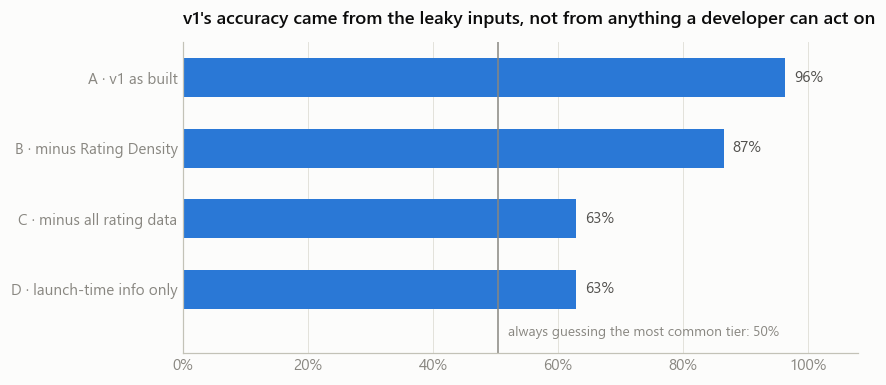

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(results))[::-1]
ax.barh(y, results["accuracy"], color=BLUE, height=0.55)
for yi, v in zip(y, results["accuracy"]):
    ax.annotate(f"{v:.0%}", (v, yi), xytext=(6, 0), textcoords="offset points", va="center", color=INK_2)
ax.axvline(majority_acc, color=MUTED, linewidth=1)
ax.annotate(f"always guessing the most common tier: {majority_acc:.0%}", (majority_acc, -0.62),
            xytext=(6, 0), textcoords="offset points", ha="left", va="center", color=MUTED, fontsize=9)
ax.set_ylim(-0.9, y.max() + 0.5)
ax.set_yticks(y, results.index)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlim(0, 1.08)
ax.set_title("v1's accuracy came from the leaky inputs, not from anything a developer can act on")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Result:** With only launch-time information (version D), v1's recipe reaches about 63%, roughly 12 points above always guessing the most common tier (51%). Everything between 63% and 96% came from rating data that only exists after launch, and 10 of those points came from the leaky density column alone. Its macro F1 drops from 97% to 40%, so it barely separates the smaller tiers. Notebook 03 builds a far better launch-time model than this recipe.

One more check: v1's original model made most of its mistakes on apps with **zero ratings**. For those apps Rating Density is 0, so the shortcut stops working.

In [5]:
test = sample.loc[test_idx]
wrong = preds_a != y_te.to_numpy()
print(f"Share of all test apps with zero ratings:      {(test['rating_count'] == 0).mean():.1%}")
print(f"Share of version A's mistakes on zero-rating apps: {(test.loc[wrong, 'rating_count'] == 0).mean():.1%}")

Share of all test apps with zero ratings:      43.2%
Share of version A's mistakes on zero-rating apps: 96.9%


### 3 · The web app sent the models differently defined inputs
Loaded v1's saved models from `v1/models/` and scored one real app from the data, **Ampere Battery Info** (Tools, 64 ratings, 4.4 stars, 7,662 installs, so truly *Emerging*). Scored it twice: once with the inputs defined as in training, once as the v1 web app builds them in `v1/utils/helpers.py`.

| Input | How the model was trained | What the v1 app sent |
|---|---|---|
| Rating Density | ratings ÷ install bucket → 64 / 5,001 = 0.013 | ratings ÷ days live → 64 / 390 = 0.164 |
| Rating Quality Score | stars × log(ratings) → 18.4 | the star rating alone → 4.4 |
| Price of a paid app | the real price | always $2.99 |
| Tier ranges shown | Low < 1K · Emerging 1K–100K · Popular 100K–10M · Viral 10M+ | 0–10K · 10K–100K · 100K–1M · 1M+ |

In [6]:
warnings.filterwarnings("ignore")
clf_v1 = joblib.load(REPO / "v1" / "models" / "xgboost_model.pkl")
feature_order = list(clf_v1.feature_names_in_)
app = dict(Category="Tools", Rating_Count=64.0, Size_MB=2.9, Free=True, Price_USD=0.0, Ad_Supported=True,
           In_App_Purchases=False, Editors_Choice=False, App_Age_Days=390)
as_trained = pd.DataFrame([{**app, "Rating_Quality_Score": 4.4 * np.log1p(64), "Rating_Density": 64 / 5001}])
as_served = pd.DataFrame([{**app, "Rating_Quality_Score": 4.4, "Rating_Density": 64 / 390}])

tiers = ["Low", "Emerging", "Popular", "Viral"]
p_trained = clf_v1.predict_proba(as_trained[feature_order])[0]
p_served = clf_v1.predict_proba(as_served[feature_order])[0]
pd.DataFrame({"inputs defined as in training": p_trained, "inputs as the v1 app sent them": p_served},
             index=tiers).style.format("{:.1%}")

,inputs defined as in training,inputs as the v1 app sent them
Low,0.0%,98.7%
Emerging,100.0%,1.3%
Popular,0.0%,0.0%
Viral,0.0%,0.0%


**Result:** Same app, same model, opposite answers. With the training definitions the model was "certain" this app is Emerging, because the leak handed it the bucket. With the app's definitions it was 99% sure the app is Low. Users of the live v1 app were seeing answers that depended on a definition mismatch, not on their app.

### 4 · What the v1 recommender actually matched on
The recommender scaled five numeric features to 0–1 with a min–max scaler, then compared apps by cosine similarity. A min–max scaler squashes heavy-tailed columns: the largest rating count was 138.6 million, so an app with 10,000 ratings scores 0.00007. Measured how much each scaled feature actually varies across apps. A feature that barely varies can't influence which apps look similar.

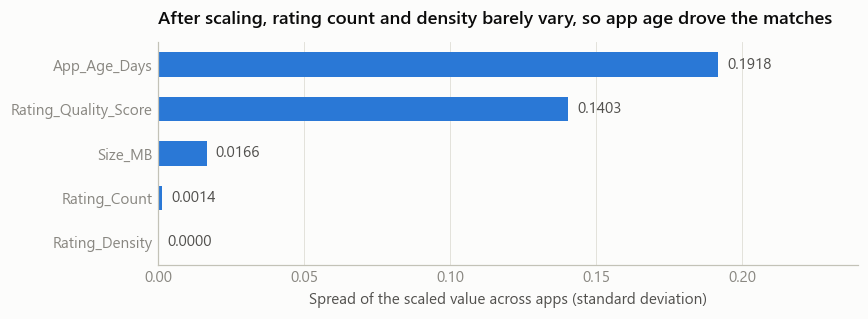

In [7]:
scaler = joblib.load(REPO / "v1" / "models" / "scaler.pkl")
num = pd.DataFrame({
    "Rating_Quality_Score": v1["Rating_Quality_Score"], "Rating_Count": v1["rating_count"],
    "Rating_Density": v1["Rating_Density"], "Size_MB": v1["size_mb"].fillna(v1["size_mb"].median()),
    "App_Age_Days": v1["age_days"],
}).sample(300_000, random_state=1)
scaled = pd.DataFrame(scaler.transform(num), columns=num.columns)
spread = scaled.std().sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(spread.index, spread.values, color=BLUE, height=0.55)
for yi, v in enumerate(spread.values):
    ax.annotate(f"{v:.4f}", (v, yi), xytext=(6, 0), textcoords="offset points", va="center", color=INK_2)
ax.set_xlabel("Spread of the scaled value across apps (standard deviation)")
ax.set_title("After scaling, rating count and density barely vary, so app age drove the matches")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, spread.max() * 1.25)
plt.tight_layout()
plt.show()

**Result:** Within a category, similarity came down to **app age**, then rating quality and size. Rating count and density contributed almost nothing. That's why v1's own example ("Unravel") returned five Tools apps all released within the same three weeks, one rated 2.1 stars. Nothing in the recommender looked for apps that *succeeded*.

### 5 · Numbers in the v1 app that no notebook produced

| Shown in v1 | What the notebooks actually contain |
|---|---|
| Recommender Precision@10 0.85 · Recall@10 0.78 · NDCG 0.82 | Never computed; there's no ground truth to compute them from |
| Regressor RMSE 0.234 · MAE 0.189 | Measured RMSE was ~16.3 million installs |
| Classifier 96.5% accuracy | Real on paper, but produced by the leak (section 2) |
| "1.2K+ Success Stories", "Editors' Choice can 10x your installs" | No source |

### What v2 does differently
- **Launch Outlook model:** uses only information a studio has before launch, is evaluated against simple baselines, and is tested on developers it never saw in training (notebook 03).
- **One shared feature module (`appvision/features.py`):** both the notebooks and the app import it, so a definition can't drift between them.
- **Playbook:** finds look-alikes by what an app *is* (wording, category, setup), then separates the ones that broke out from the ones that stalled (notebook 04).
- **Every metric the app displays** is read from a file the notebooks write. None is typed by hand.